# 06 — LLM Data Augmentation

**Project:** Syllabus Policy Stance Detection  
**Author:** Charitha  
**Purpose:** Use Llama-3 via Groq API to generate synthetic training sentences
for minority classes, then validate and merge with real data.

---

## Why augmentation?
From notebook 02, classical ML hit a hard ceiling with:
- Conditional F1  : 0.333 (barely above random)
- Encouraging F1  : 0.667 (reasonable but limited by 28 examples)

Root cause: insufficient minority class examples.
- Conditional  : 34 real examples
- Encouraging  : 28 real examples
- Discouraging : 292 real examples

## Augmentation strategy:
- Target: ~100 examples per minority class
- Generate: ~70 synthetic conditional + ~75 synthetic encouraging
- Validate: automatic quality checks + manual spot review
- Split rule: synthetic data goes into TRAINING ONLY, never test set

## Why Groq + Llama-3?
- Free API tier sufficient for our scale
- Llama-3 70B understands academic register well
- Fast inference (~100 sentences in ~2 minutes)

---

## Cell 1 — Install and Import

In [1]:
# Install groq client (first time only)
import subprocess
subprocess.run(['pip', 'install', 'groq', '-q'], capture_output=True)
print('Groq installed!')

Groq installed!


In [2]:
# import subprocess

# # Downgrade to compatible versions
# subprocess.run(['pip', 'install', 'typing_extensions==4.12.2', '-q'], capture_output=True)
# subprocess.run(['pip', 'install', 'pydantic==2.9.2', '-q'], capture_output=True)
# subprocess.run(['pip', 'install', 'groq==0.9.0', '-q'], capture_output=True)

# print('Done! Now restart your kernel and rerun from Cell 1.')

In [3]:
import pandas as pd
import numpy as np
import os
import json
import time
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from groq import Groq

print('Libraries loaded!')

Libraries loaded!


## Cell 2 — Paths and Config

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH        = '../data/processed/policy_relevant_clean.csv'
AUG_RAW_PATH     = '../data/processed/augmented_raw.csv'        # synthetic only
AUG_MERGED_PATH  = '../data/processed/augmented_merged.csv'     # real + synthetic
ANALYSIS_DIR     = '../analysis/'

os.makedirs('../data/processed', exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

RANDOM_SEED = 42
LABELS = ['discouraging', 'conditional', 'encouraging']

# ── Groq config ────────────────────────────────────────────────────────────
# Paste your Groq API key here
GROQ_API_KEY = "your-groq-api-key-here"  

# Model: llama-3.3-70b-versatile — best free model on Groq for text generation
GROQ_MODEL = 'llama-3.3-70b-versatile'

# How many synthetic sentences to generate per class
# Target: real + synthetic ≈ 100 per minority class
N_CONDITIONAL  = 70   # 34 real + 70 synthetic = 104 total
N_ENCOURAGING  = 75   # 28 real + 75 synthetic = 103 total
# Discouraging: 292 real — no augmentation needed

# Batch size: how many sentences to request per API call
# Smaller batches = more reliable JSON parsing
BATCH_SIZE = 10

print('Config set!')
print(f'Generating: {N_CONDITIONAL} conditional + {N_ENCOURAGING} encouraging sentences')
print(f'Model: {GROQ_MODEL}')

Config set!
Generating: 70 conditional + 75 encouraging sentences
Model: llama-3.3-70b-versatile


## Cell 3 — Load Real Data and Extract Examples

We load real examples from each class to use as:
1. **Few-shot examples** in the prompt (shows the model what real sentences look like)
2. **Deduplication reference** (ensures synthetic sentences don't repeat real ones)

In [5]:
df = pd.read_csv(DATA_PATH)

# Separate by class
disc_df  = df[df['stance'] == 'discouraging'].reset_index(drop=True)
cond_df  = df[df['stance'] == 'conditional'].reset_index(drop=True)
enc_df   = df[df['stance'] == 'encouraging'].reset_index(drop=True)

print('Real data loaded:')
print(f'  Discouraging : {len(disc_df)} sentences')
print(f'  Conditional  : {len(cond_df)} sentences')
print(f'  Encouraging  : {len(enc_df)} sentences')
print()

# Sample few-shot examples for prompts (use 5 diverse real examples per class)
np.random.seed(RANDOM_SEED)
cond_examples = cond_df['sentence'].sample(min(5, len(cond_df)), random_state=RANDOM_SEED).tolist()
enc_examples  = enc_df['sentence'].sample(min(5, len(enc_df)),  random_state=RANDOM_SEED).tolist()

print('Few-shot examples selected for prompts:')
print('\nConditional examples:')
for i, ex in enumerate(cond_examples, 1):
    print(f'  {i}. {ex}')
print('\nEncouraging examples:')
for i, ex in enumerate(enc_examples, 1):
    print(f'  {i}. {ex}')

Real data loaded:
  Discouraging : 292 sentences
  Conditional  : 34 sentences
  Encouraging  : 28 sentences

Few-shot examples selected for prompts:

Conditional examples:
  1. References must come from peer-reviewed journals, up-to-date physical therapy or medical textbooks or publications, or APTA publications. Wikipedia may not be used as a cited reference source. Be submitted in an electronic format (paper documents will not be accepted), and your assignment must be in the file format of a Microsoft Word or Adobe PDF document.  M  5.  PL E  For this course, each student shall use the Wor-Wic electronic resource center to identify reference materials to support a research paper on the following topic: create a professional development plan for your first two years after graduation
  2. Encyclopedic sources [including Wikipedia] and journalistic news or feature pieces or purely informational product data items are preliminary reference information, but SHOULD NOT be referenced or pa

## Cell 4 — Define Prompt Templates

### Why prompt design matters:
The quality of synthetic data is entirely determined by how well you
describe the task to the LLM. We need:
1. Clear label definitions (what makes a sentence 'conditional'?)
2. Real examples (few-shot learning)
3. Explicit constraints (academic register, Wikipedia-specific, no duplicates)
4. Structured output (JSON for reliable parsing)

### Label definitions used:
- **Conditional**: Allows Wikipedia use BUT with explicit restrictions,
  qualifications, or conditions. Key linguistic markers: 'only as',
  'provided that', 'may be used if', 'with caution', 'as a starting point'
- **Encouraging**: Positively recommends or endorses Wikipedia use.
  Key markers: 'encouraged', 'recommended', 'useful resource',
  'feel free to', 'is a good starting point'

In [6]:
def build_prompt(stance_label, real_examples, n_sentences):
    """
    Build a few-shot prompt for generating synthetic stance sentences.

    Parameters:
        stance_label  : str  — 'conditional' or 'encouraging'
        real_examples : list — real sentences from that class (few-shot)
        n_sentences   : int  — how many to generate

    Returns:
        str — the full prompt
    """

    # Label-specific definition and constraints
    if stance_label == 'conditional':
        definition = (
            "CONDITIONAL stance: The sentence allows or permits Wikipedia use "
            "BUT imposes explicit restrictions, qualifications, or conditions. "
            "It neither fully endorses nor fully prohibits Wikipedia. "
            "Key linguistic markers: 'only as a starting point', 'with caution', "
            "'may be used if', 'provided that', 'not as a primary source', "
            "'consult but verify', 'acceptable only for', 'limited to'."
        )
        variation_instruction = (
            "Vary the conditions imposed: some about citation rules, "
            "some about verification requirements, some about acceptable use cases, "
            "some about depth of reliance. Use different sentence structures."
        )
    else:  # encouraging
        definition = (
            "ENCOURAGING stance: The sentence positively recommends, endorses, "
            "or actively promotes the use of Wikipedia. "
            "Key linguistic markers: 'encouraged to use', 'recommended resource', "
            "'is a valuable tool', 'feel free to consult', 'Wikipedia provides', "
            "'students are welcome to', 'a good starting point'."
        )
        variation_instruction = (
            "Vary the context: some sentences from science courses, some from "
            "humanities, some general. Vary the tone from neutral-positive to "
            "enthusiastically positive. Use different sentence structures."
        )

    examples_text = '\n'.join([f'  - "{ex}"' for ex in real_examples])

    prompt = f"""You are a dataset generator for an NLP research project on university syllabus policy analysis.

TASK: Generate {n_sentences} synthetic university syllabus sentences with a {stance_label.upper()} stance toward Wikipedia use.

DEFINITION:
{definition}

REAL EXAMPLES from actual syllabi (use these as style and tone reference):
{examples_text}

REQUIREMENTS:
1. Each sentence must sound like it came from a real university course syllabus
2. Each sentence must specifically reference Wikipedia (not just 'internet sources')
3. Use formal academic language — the register of course policy documents
4. {variation_instruction}
5. Do NOT copy the example sentences — generate new, distinct sentences
6. Do NOT number the sentences in the output
7. Each sentence should be 1-3 sentences long (policy statement length)

OUTPUT FORMAT: Return ONLY a valid JSON array of strings. No preamble, no explanation, no markdown.
Example format: ["sentence one here", "sentence two here", "sentence three here"]

Generate exactly {n_sentences} sentences now:"""

    return prompt


# Preview the prompt for conditional
test_prompt = build_prompt('conditional', cond_examples[:3], 3)
print('=== PROMPT PREVIEW (conditional, 3 sentences) ===')
print(test_prompt)
print()
print('Prompt looks good! Ready to call Groq API.')

=== PROMPT PREVIEW (conditional, 3 sentences) ===
You are a dataset generator for an NLP research project on university syllabus policy analysis.

TASK: Generate 3 synthetic university syllabus sentences with a CONDITIONAL stance toward Wikipedia use.

DEFINITION:
CONDITIONAL stance: The sentence allows or permits Wikipedia use BUT imposes explicit restrictions, qualifications, or conditions. It neither fully endorses nor fully prohibits Wikipedia. Key linguistic markers: 'only as a starting point', 'with caution', 'may be used if', 'provided that', 'not as a primary source', 'consult but verify', 'acceptable only for', 'limited to'.

REAL EXAMPLES from actual syllabi (use these as style and tone reference):
  - "References must come from peer-reviewed journals, up-to-date physical therapy or medical textbooks or publications, or APTA publications. Wikipedia may not be used as a cited reference source. Be submitted in an electronic format (paper documents will not be accepted), and you

## Cell 5 — Define API Call Function

We generate in batches of 10 sentences per API call.
Why batches?
- Smaller requests = more reliable JSON parsing
- Easier to retry if one batch fails
- Groq rate limits are per-request, not per-sentence

In [7]:
# import subprocess

# subprocess.run(['pip', 'install', 'httpx==0.27.2', '-q'], capture_output=True)
# print('Done! Restart kernel and rerun from Cell 1.')

In [8]:
# Initialize Groq client
client = Groq(api_key=GROQ_API_KEY)


def generate_batch(stance_label, real_examples, n, max_retries=3):
    """
    Call Groq API to generate n synthetic sentences for a given stance.
    Retries up to max_retries times if JSON parsing fails.

    Returns:
        list of strings — generated sentences
    """
    prompt = build_prompt(stance_label, real_examples, n)

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model    = GROQ_MODEL,
                messages = [{'role': 'user', 'content': prompt}],
                temperature = 0.85,   # some creativity but not chaotic
                max_tokens  = 2000,
            )

            raw_text = response.choices[0].message.content.strip()

            # Clean up common LLM output artifacts before parsing
            # Remove markdown code blocks if present
            raw_text = re.sub(r'```json\s*', '', raw_text)
            raw_text = re.sub(r'```\s*',     '', raw_text)
            raw_text = raw_text.strip()

            # Extract JSON array
            # Find the first '[' and last ']' to isolate the array
            start = raw_text.find('[')
            end   = raw_text.rfind(']') + 1
            if start == -1 or end == 0:
                raise ValueError(f'No JSON array found in response: {raw_text[:200]}')

            json_str  = raw_text[start:end]
            sentences = json.loads(json_str)

            if not isinstance(sentences, list):
                raise ValueError('Parsed JSON is not a list')

            return [str(s).strip() for s in sentences if str(s).strip()]

        except (json.JSONDecodeError, ValueError) as e:
            print(f'  Attempt {attempt+1} failed: {e}')
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                print(f'  All {max_retries} attempts failed for this batch. Skipping.')
                return []

        except Exception as e:
            print(f'  API error on attempt {attempt+1}: {e}')
            time.sleep(5)
            if attempt == max_retries - 1:
                return []

    return []


# Test with one sentence to verify API connection
print('Testing Groq API connection...')
test_result = generate_batch('conditional', cond_examples, 2)
if test_result:
    print(f'API connection successful!')
    print(f'Sample output:')
    for s in test_result:
        print(f'  - {s}')
else:
    print('API test failed — check your API key in Cell 2')

Testing Groq API connection...
API connection successful!
Sample output:
  - Students are permitted to consult Wikipedia as a preliminary resource for background information, provided that they verify all facts and data through reputable academic sources before incorporation into their research papers.
  - While Wikipedia may be used as a starting point for exploration of a topic, it should not be cited as a primary source in any assignment, and students are expected to supplement their research with peer-reviewed articles and scholarly books.


## Cell 6 — Generate Conditional Sentences

Generating in batches of 10. Target: 70 conditional sentences.
This will make ~7 API calls, should complete in under 2 minutes.

In [9]:
def generate_all(stance_label, real_examples, total_needed, batch_size=BATCH_SIZE):
    """
    Generate total_needed sentences in batches.
    Shows progress and handles partial batches.
    """
    all_sentences = []
    n_batches     = (total_needed + batch_size - 1) // batch_size  # ceiling division

    print(f'Generating {total_needed} {stance_label} sentences in {n_batches} batches...')
    print()

    for i in range(n_batches):
        # Last batch may be smaller
        remaining  = total_needed - len(all_sentences)
        batch_n    = min(batch_size, remaining)

        print(f'  Batch {i+1}/{n_batches} — requesting {batch_n} sentences...')
        batch = generate_batch(stance_label, real_examples, batch_n)
        all_sentences.extend(batch)

        print(f'  Got {len(batch)} sentences. Total so far: {len(all_sentences)}')

        # Polite pause between API calls
        if i < n_batches - 1:
            time.sleep(1)

    print(f'\nGeneration complete: {len(all_sentences)} {stance_label} sentences')
    return all_sentences


# Generate conditional sentences
print('=' * 55)
print('  GENERATING CONDITIONAL SENTENCES')
print('=' * 55)
synthetic_conditional = generate_all('conditional', cond_examples, N_CONDITIONAL)

print()
print('Sample generated conditional sentences:')
for s in synthetic_conditional[:5]:
    print(f'  - {s}')

  GENERATING CONDITIONAL SENTENCES
Generating 70 conditional sentences in 7 batches...

  Batch 1/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 10
  Batch 2/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 20
  Batch 3/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 30
  Batch 4/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 40
  Batch 5/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 50
  Batch 6/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 60
  Batch 7/7 — requesting 10 sentences...
  Got 10 sentences. Total so far: 70

Generation complete: 70 conditional sentences

Sample generated conditional sentences:
  - While Wikipedia may be consulted for general information, it should not be cited as a primary source in research papers, and students are expected to verify any information obtained from Wikipedia through more reliable sources.
  - Wikipedia can be used as a starting point 

## Cell 7 — Generate Encouraging Sentences

In [10]:
print('=' * 55)
print('  GENERATING ENCOURAGING SENTENCES')
print('=' * 55)
synthetic_encouraging = generate_all('encouraging', enc_examples, N_ENCOURAGING)

print()
print('Sample generated encouraging sentences:')
for s in synthetic_encouraging[:5]:
    print(f'  - {s}')

  GENERATING ENCOURAGING SENTENCES
Generating 75 encouraging sentences in 8 batches...

  Batch 1/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 10
  Batch 2/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 20
  Batch 3/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 30
  Batch 4/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 40
  Batch 5/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 50
  Batch 6/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 60
  Batch 7/8 — requesting 10 sentences...
  Got 10 sentences. Total so far: 70
  Batch 8/8 — requesting 5 sentences...
  Got 5 sentences. Total so far: 75

Generation complete: 75 encouraging sentences

Sample generated encouraging sentences:
  - Students are encouraged to use Wikipedia as a starting point for research in this course, as it provides a comprehensive overview of key concepts and terminology in the field of environmental scienc

## Cell 8 — Quality Validation

### Why validate synthetic data?
LLMs can produce:
- Sentences that don't mention Wikipedia
- Sentences that are too short / too long to be real policy text
- Near-duplicate sentences
- Sentences that contradict the intended label

We apply automatic filters first, then you manually review a sample.

### Automatic filters applied:
1. Must contain 'wikipedia' (case-insensitive)
2. Length: 5-100 words (policy sentence range)
3. No near-duplicates (within synthetic set)
4. No exact matches with real data

In [11]:
def validate_sentences(sentences, real_sentences, stance_label):
    """
    Apply automatic quality filters to synthetic sentences.

    Filters:
    1. Must mention Wikipedia
    2. Word count between 5 and 100
    3. No exact duplicates within synthetic set
    4. No exact matches with real sentences

    Returns:
        clean list, and a report dict
    """
    original_n  = len(sentences)
    real_lower  = set(s.lower().strip() for s in real_sentences)
    seen        = set()
    clean       = []
    rejected    = {'no_wikipedia': [], 'too_short': [], 'too_long': [],
                   'duplicate': [], 'matches_real': []}

    for s in sentences:
        s = s.strip()
        words = s.split()
        s_lower = s.lower()

        # Filter 1: must mention wikipedia
        if 'wikipedia' not in s_lower:
            rejected['no_wikipedia'].append(s)
            continue

        # Filter 2: length check
        if len(words) < 5:
            rejected['too_short'].append(s)
            continue
        if len(words) > 100:
            rejected['too_long'].append(s)
            continue

        # Filter 3: internal duplicates
        if s_lower in seen:
            rejected['duplicate'].append(s)
            continue

        # Filter 4: matches real data
        if s_lower in real_lower:
            rejected['matches_real'].append(s)
            continue

        seen.add(s_lower)
        clean.append(s)

    print(f'\n=== VALIDATION REPORT: {stance_label} ===')
    print(f'  Original generated : {original_n}')
    print(f'  Passed all filters : {len(clean)}')
    print(f'  Rejected breakdown :')
    for reason, items in rejected.items():
        if items:
            print(f'    {reason:<20}: {len(items)}')
            for item in items[:2]:   # show first 2 examples
                print(f'      e.g. "{item[:80]}..."' if len(item) > 80 else f'      e.g. "{item}"')

    return clean, rejected


# Validate both classes
real_all = df['sentence'].tolist()

clean_conditional, rej_cond = validate_sentences(
    synthetic_conditional, real_all, 'conditional'
)
clean_encouraging, rej_enc  = validate_sentences(
    synthetic_encouraging, real_all, 'encouraging'
)

print(f'\nClean synthetic sentences:')
print(f'  Conditional : {len(clean_conditional)}')
print(f'  Encouraging : {len(clean_encouraging)}')


=== VALIDATION REPORT: conditional ===
  Original generated : 70
  Passed all filters : 70
  Rejected breakdown :

=== VALIDATION REPORT: encouraging ===
  Original generated : 75
  Passed all filters : 75
  Rejected breakdown :

Clean synthetic sentences:
  Conditional : 70
  Encouraging : 75


## Cell 9 — Manual Spot Review

**This cell requires your judgment.**

Automatic filters catch structural problems but cannot catch semantic ones
e.g. a sentence that mentions Wikipedia but is actually discouraging in tone
despite being labelled conditional.

Review the samples below. If you see sentences that look wrong,
add their indices to the REJECT lists and rerun Cell 10.

In [12]:
print('=' * 65)
print('  MANUAL REVIEW — CONDITIONAL sentences')
print('  Check: does each sentence ALLOW Wikipedia WITH conditions?')
print('  If a sentence sounds discouraging or encouraging instead → note its index')
print('=' * 65)
for i, s in enumerate(clean_conditional):
    print(f'  [{i:02d}] {s}')

print()
print('=' * 65)
print('  MANUAL REVIEW — ENCOURAGING sentences')
print('  Check: does each sentence POSITIVELY recommend Wikipedia?')
print('  If a sentence sounds discouraging or conditional instead → note its index')
print('=' * 65)
for i, s in enumerate(clean_encouraging):
    print(f'  [{i:02d}] {s}')

  MANUAL REVIEW — CONDITIONAL sentences
  Check: does each sentence ALLOW Wikipedia WITH conditions?
  If a sentence sounds discouraging or encouraging instead → note its index
  [00] While Wikipedia may be consulted for general information, it should not be cited as a primary source in research papers, and students are expected to verify any information obtained from Wikipedia through more reliable sources.
  [01] Wikipedia can be used as a starting point for research, but students must consult at least three additional peer-reviewed sources to support their arguments and provide a comprehensive understanding of the topic.
  [02] Students are permitted to use Wikipedia for background research, provided that they do not rely solely on it and instead use it as a means to identify more credible sources, which will be evaluated based on their academic rigor and relevance to the topic.
  [03] References to Wikipedia are acceptable only for introductory or exploratory purposes, and students

## Cell 10 — Remove Manually Flagged Sentences

Add indices of sentences you want to remove to the lists below.
If everything looks good, leave both lists empty.

In [15]:
# ── ADD INDICES TO REJECT HERE ─────────────────────────────────────────────
# Example: if sentence [03] and [07] in conditional look wrong:
# REJECT_CONDITIONAL = [3, 7]

REJECT_CONDITIONAL = [19,67]   # ← add indices here if needed
REJECT_ENCOURAGING = [3, 13, 15, 22, 25, 28, 35, 41, 53, 61, 66, 69, 71, 73]   # ← add indices here if needed

# Apply manual rejections
final_conditional = [s for i, s in enumerate(clean_conditional)
                     if i not in REJECT_CONDITIONAL]
final_encouraging = [s for i, s in enumerate(clean_encouraging)
                     if i not in REJECT_ENCOURAGING]

print(f'Final synthetic counts after manual review:')
print(f'  Conditional : {len(final_conditional)} (removed {len(REJECT_CONDITIONAL)})')
print(f'  Encouraging : {len(final_encouraging)} (removed {len(REJECT_ENCOURAGING)})')
print()
print(f'Total synthetic sentences: {len(final_conditional) + len(final_encouraging)}')

Final synthetic counts after manual review:
  Conditional : 68 (removed 2)
  Encouraging : 61 (removed 14)

Total synthetic sentences: 129


## Cell 11 — Build Augmented Dataset

### Critical rule: synthetic data is TRAINING ONLY

We mark each sentence with a `source` column:
- `source = 'real'`      → can go in train or test
- `source = 'synthetic'` → training only, NEVER in test set

This ensures your test set evaluation reflects performance on real data only.
Using synthetic data in the test set would be data leakage.

In [17]:
# Build synthetic dataframe
synthetic_rows = (
    [{'sentence': s, 'stance': 'conditional', 'source': 'synthetic'}
     for s in final_conditional] +
    [{'sentence': s, 'stance': 'encouraging', 'source': 'synthetic'}
     for s in final_encouraging]
)
df_synthetic = pd.DataFrame(synthetic_rows)

# Add source column to real data
df_real = df.copy()
df_real['source'] = 'real'

# Merge
df_merged = pd.concat([df_real, df_synthetic], ignore_index=True)
df_merged = df_merged.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print('=== AUGMENTED DATASET SUMMARY ===')
print(f'Total sentences: {len(df_merged)}')
print()
print('By class and source:')
summary = df_merged.groupby(['stance', 'source']).size().unstack(fill_value=0)
print(summary)
print()
print('Class totals (real + synthetic):')
print(df_merged['stance'].value_counts())
print()

# Imbalance ratio before vs after
before_ratio = 292 / 28
enc_total    = len(df_merged[df_merged['stance'] == 'encouraging'])
after_ratio  = 292 / enc_total
print(f'Imbalance ratio (disc/enc): {before_ratio:.1f}x → {after_ratio:.1f}x')
print('(lower = more balanced)')

=== AUGMENTED DATASET SUMMARY ===
Total sentences: 483

By class and source:
source        real  synthetic
stance                       
conditional     34         68
discouraging   292          0
encouraging     28         61

Class totals (real + synthetic):
stance
discouraging    292
conditional     102
encouraging      89
Name: count, dtype: int64

Imbalance ratio (disc/enc): 10.4x → 3.3x
(lower = more balanced)


## Cell 12 — Visualize Before vs After Augmentation

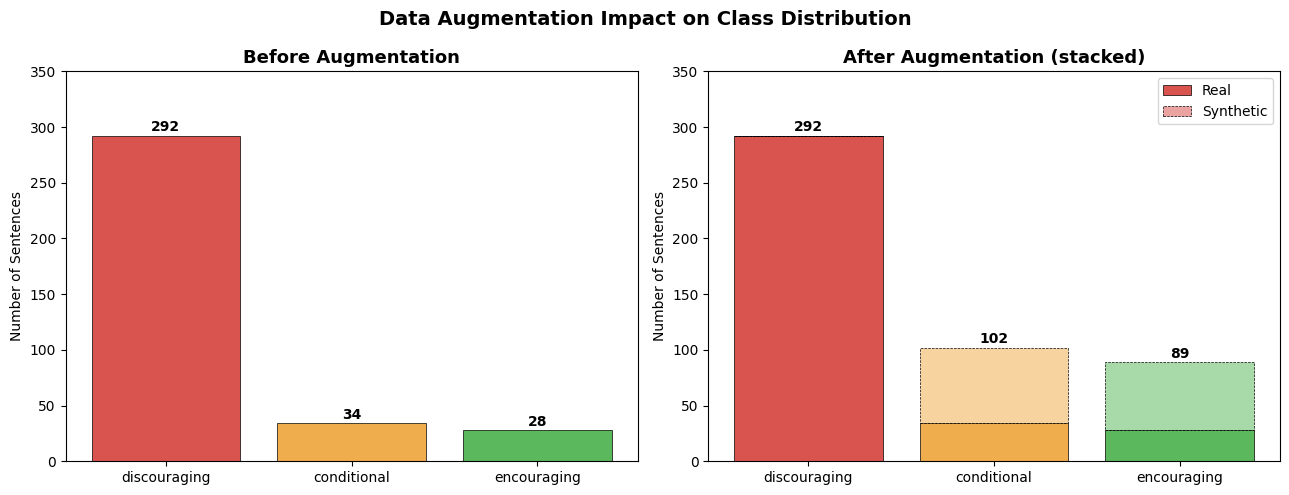

Figure saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors    = ['#d9534f', '#f0ad4e', '#5cb85c']

# Before
before_counts = df['stance'].value_counts().reindex(LABELS)
axes[0].bar(before_counts.index, before_counts.values,
            color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Before Augmentation', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Sentences')
axes[0].set_ylim(0, 350)
for i, (label, count) in enumerate(before_counts.items()):
    axes[0].text(i, count + 4, str(count), ha='center', fontweight='bold')

# After — stacked bars (real vs synthetic)
real_counts = df_merged[df_merged['source'] == 'real'].groupby('stance').size().reindex(LABELS, fill_value=0)
syn_counts  = df_merged[df_merged['source'] == 'synthetic'].groupby('stance').size().reindex(LABELS, fill_value=0)

x = np.arange(len(LABELS))
b1 = axes[1].bar(x, real_counts.values, color=colors,
                  edgecolor='black', linewidth=0.5, label='Real')
b2 = axes[1].bar(x, syn_counts.values, bottom=real_counts.values,
                  color=[c + '88' for c in ['#d9534f', '#f0ad4e', '#5cb85c']],
                  edgecolor='black', linewidth=0.5, linestyle='--', label='Synthetic')
axes[1].set_xticks(x)
axes[1].set_xticklabels(LABELS)
axes[1].set_title('After Augmentation (stacked)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Sentences')
axes[1].set_ylim(0, 350)
axes[1].legend()
totals = real_counts.values + syn_counts.values
for i, total in enumerate(totals):
    axes[1].text(i, total + 4, str(total), ha='center', fontweight='bold')

plt.suptitle('Data Augmentation Impact on Class Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}06_augmentation_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## Cell 13 — Save Datasets

In [19]:
# Save synthetic-only file (for inspection and reproducibility)
df_synthetic.to_csv(AUG_RAW_PATH, index=False, encoding='utf-8')
print(f'Synthetic sentences saved : {AUG_RAW_PATH}')
print(f'  Rows: {len(df_synthetic)}')

# Save merged file (this is what notebook 03 will use)
df_merged.to_csv(AUG_MERGED_PATH, index=False, encoding='utf-8')
print(f'Merged dataset saved      : {AUG_MERGED_PATH}')
print(f'  Rows: {len(df_merged)}')
print(f'  Columns: {df_merged.columns.tolist()}')

# Verify
df_check = pd.read_csv(AUG_MERGED_PATH)
print()
print('Verification — reloaded from disk:')
print(df_check['stance'].value_counts())
print(df_check['source'].value_counts())

Synthetic sentences saved : ../data/processed/augmented_raw.csv
  Rows: 129
Merged dataset saved      : ../data/processed/augmented_merged.csv
  Rows: 483
  Columns: ['sentence', 'stance', 'source']

Verification — reloaded from disk:
stance
discouraging    292
conditional     102
encouraging      89
Name: count, dtype: int64
source
real         354
synthetic    129
Name: count, dtype: int64


## Cell 14 — Summary

In [20]:
print('=' * 60)
print('  NOTEBOOK 06 COMPLETE — SUMMARY')
print('=' * 60)
print()
print('What we did:')
print('  1. Used Llama-3 via Groq to generate synthetic sentences')
print('  2. Applied automatic quality filters (Wikipedia mention,')
print('     length, deduplication, real-data overlap)')
print('  3. Manual spot review of all generated sentences')
print('  4. Merged real + synthetic into augmented_merged.csv')
print('  5. Marked source column (real/synthetic) for data leakage prevention')
print()

cond_total = len(df_merged[df_merged['stance'] == 'conditional'])
enc_total  = len(df_merged[df_merged['stance'] == 'encouraging'])
disc_total = len(df_merged[df_merged['stance'] == 'discouraging'])

print('Final dataset composition:')
print(f'  Discouraging : {disc_total} (all real)')
print(f'  Conditional  : {cond_total} ({len(cond_df)} real + {cond_total - len(cond_df)} synthetic)')
print(f'  Encouraging  : {enc_total} ({len(enc_df)} real + {enc_total - len(enc_df)} synthetic)')
print()
print('Critical rule for notebook 03:')
print('  When splitting train/test, use source column to ensure')
print('  synthetic sentences go to TRAINING ONLY.')
print('  Test set = real sentences only.')
print()
print('Next step: 03_scibert_finetuning.ipynb')
print('  Input  : augmented_merged.csv')
print('  Target : F1-Macro > 0.75 (vs classical ceiling of 0.55)')
print('=' * 60)

  NOTEBOOK 06 COMPLETE — SUMMARY

What we did:
  1. Used Llama-3 via Groq to generate synthetic sentences
  2. Applied automatic quality filters (Wikipedia mention,
     length, deduplication, real-data overlap)
  3. Manual spot review of all generated sentences
  4. Merged real + synthetic into augmented_merged.csv
  5. Marked source column (real/synthetic) for data leakage prevention

Final dataset composition:
  Discouraging : 292 (all real)
  Conditional  : 102 (34 real + 68 synthetic)
  Encouraging  : 89 (28 real + 61 synthetic)

Critical rule for notebook 03:
  When splitting train/test, use source column to ensure
  synthetic sentences go to TRAINING ONLY.
  Test set = real sentences only.

Next step: 03_scibert_finetuning.ipynb
  Input  : augmented_merged.csv
  Target : F1-Macro > 0.75 (vs classical ceiling of 0.55)
